# Taller: Redes Neuronales

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de redes neuronales de una capa y multicapa. El taller está constituido por 4 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción probabilidad de admisión a la universidad

En este taller se usará el conjunto de datos de admisiones a una universidad proveniente de la base de datos de Kaggle. Cada observación contiene la probabilidad de que un estudiante sea admitido por la universidad, dadas distintas variables predictoras como el puntaje del examén TOEFL y GRE, el promedio (GPA), entre otras. El objetivo es predecir la probabilidad de admissión de cada estudiante. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/mohansacharya/graduate-admissions).

In [14]:
import warnings
warnings.filterwarnings('ignore')

In [15]:
# Importación librerías
import numpy as np
import keras 
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from keras import initializers
from keras import optimizers
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout

In [16]:
# Carga de datos de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/universityGraduateAdmissions.csv', index_col=0)
data.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
Serial No.,,,,,,,,
1,337,118,4,4.5,4.5,9.65,1,0.92
2,324,107,4,4.0,4.5,8.87,1,0.76
3,316,104,3,3.0,3.5,8.00,1,0.72
4,322,110,3,3.5,2.5,8.67,1,0.80
5,314,103,2,2.0,3.0,8.21,0,0.65


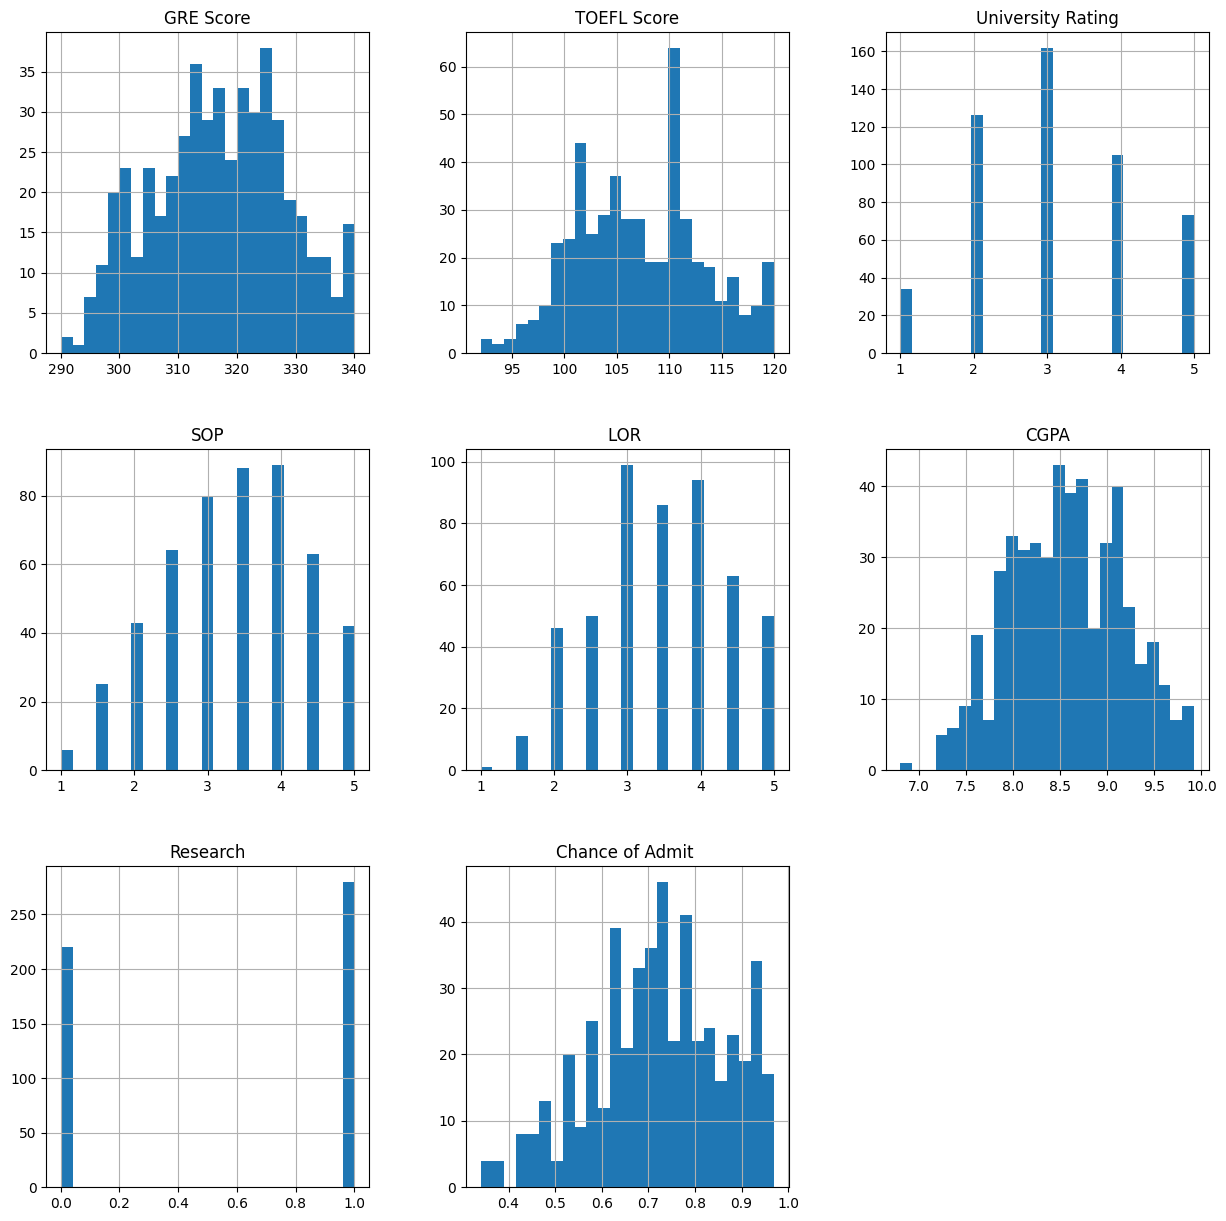

In [17]:
# Hitogramas de las varaibles del dataset
data.hist(bins=25, figsize=(15,15))
plt.show()

In [18]:
# Definición de variables predictoras (X)
X = data.drop(data.columns[-1], axis=1)
# Definición de variable de interés (y)
Y = data[data.columns[-1]]

In [19]:
# Separación de variables predictoras (X) y variable de interés (y) en set de entrenamiento y test usandola función train_test_split
xTrain, xTest, yTrain, yTest = train_test_split(X,Y,test_size=0.3, random_state=22)

## Punto 1 - Red Neuronal de una capa

En la celda 1 creen una **red neuronal de una capa** con la librería Keras, que prediga la probabilidad de admisión de los estudiantes, usando los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador y el número de épocas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

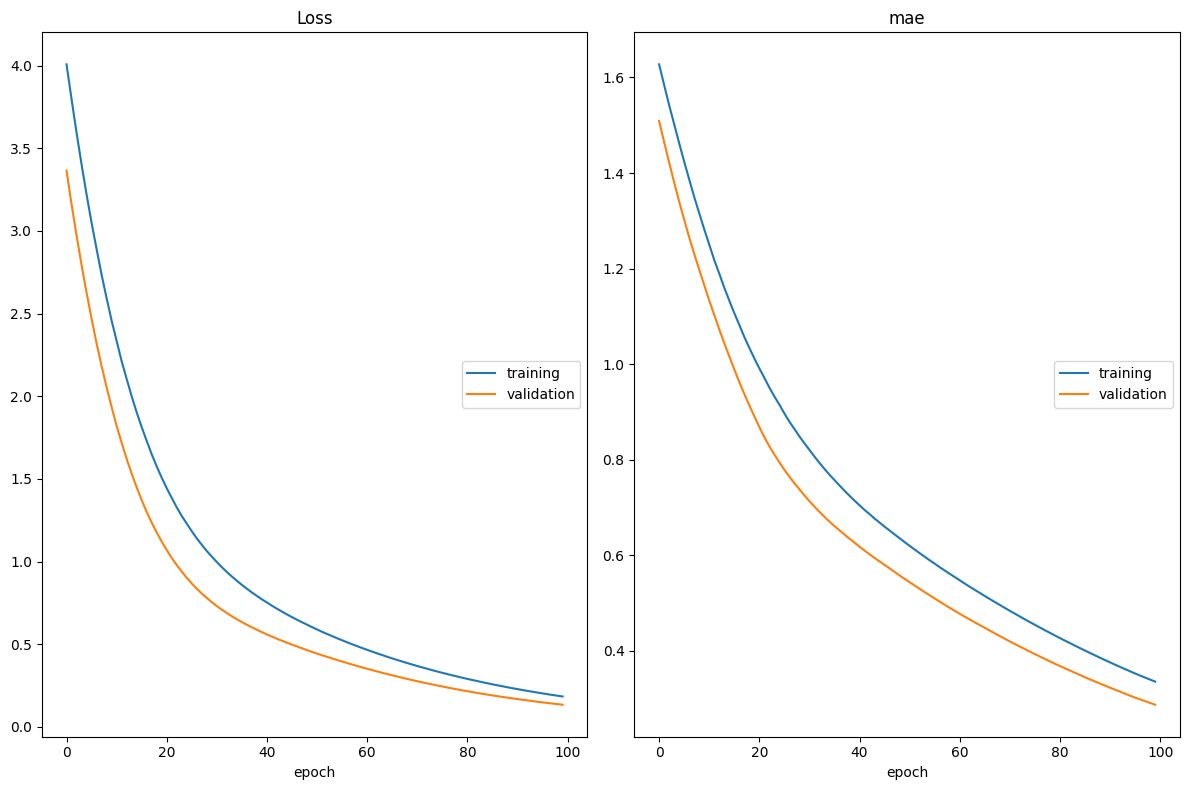

Loss
	training         	 (min:    0.184, max:    4.007, cur:    0.184)
	validation       	 (min:    0.134, max:    3.365, cur:    0.134)
mae
	training         	 (min:    0.336, max:    1.627, cur:    0.336)
	validation       	 (min:    0.288, max:    1.509, cur:    0.288)
5/5 [==============================] - 0s 2ms/step

 RESULTADOS MODELO 1 CAPA 
Error Absoluto Medio (MAE): 0.2875
Error Cuadrático Medio (MSE): 0.1344
Raíz del Error Cuadrático Medio (RMSE): 0.3666


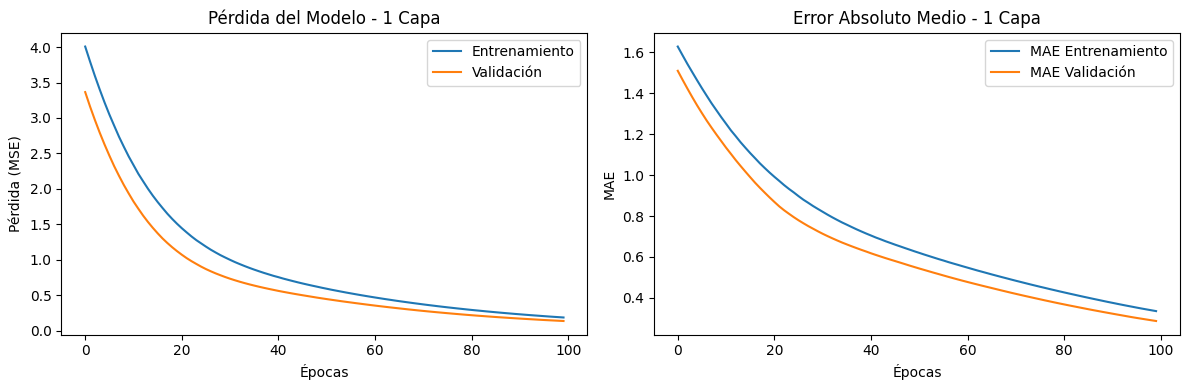

In [ ]:
# Punto 1: Red Neuronal de una capa
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from keras.callbacks import EarlyStopping
from livelossplot import PlotLossesKeras
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Normalización de datos
scaler = StandardScaler()
xTrain_scaled = scaler.fit_transform(xTrain)
xTest_scaled = scaler.transform(xTest)

# Definición de dimensiones
input_dim = xTrain_scaled.shape[1]
output_dim = 1


# Limpieza de sesión anterior
keras.backend.clear_session()

# Creación del modelo de una capa
model_1layer = Sequential()
model_1layer.add(Dense(output_dim, input_shape=(input_dim,), activation='linear'))

# Compilación del modelo
model_1layer.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])


# Entrenamiento del modelo
red_1capa = model_1layer.fit(
    xTrain_scaled, yTrain,
    epochs=100,
    batch_size=32,
    validation_data=(xTest_scaled, yTest),
    verbose=1,
    callbacks=[PlotLossesKeras()]
)

# Predicciones
y_pred_1layer = model_1layer.predict(xTest_scaled)

# Métricas de evaluación
mae_1layer = mean_absolute_error(yTest, y_pred_1layer)
mse_1layer = mean_squared_error(yTest, y_pred_1layer)

print(f"\n MODELO 1 CAPA ")
print(f"Error Absoluto Medio (MAE): {mae_1layer:.4f}")
print(f"Error Cuadrático Medio (MSE): {mse_1layer:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {np.sqrt(mse_1layer):.4f}")

# Gráfico de pérdida
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(red_1capa.history['loss'], label='Entrenamiento')
plt.plot(red_1capa.history['val_loss'], label='Validación')
plt.title('Pérdida del Modelo - 1 Capa')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (MSE)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(red_1capa.history['mae'], label='MAE Entrenamiento')
plt.plot(red_1capa.history['val_mae'], label='MAE Validación')
plt.title('Error Absoluto Medio - 1 Capa')
plt.xlabel('Épocas')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()


## Punto 2 - Red Neuronal multicapa

En la celda 2 creen una **red neuronal con dos capas** con la librería Keras, que prediga la probabilidad de admisión de los estudiantes usando los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador, el número de épocas y el número de neuronas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

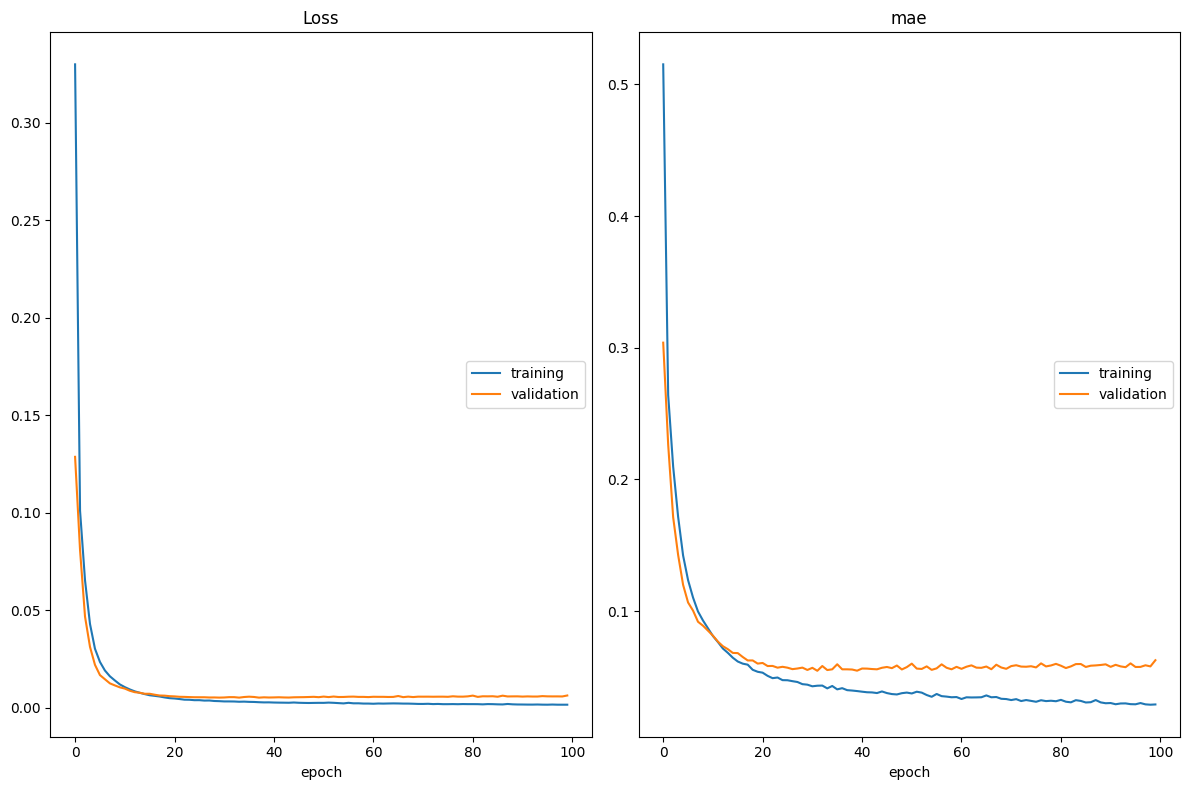

Loss
	training         	 (min:    0.002, max:    0.330, cur:    0.002)
	validation       	 (min:    0.005, max:    0.129, cur:    0.006)
mae
	training         	 (min:    0.029, max:    0.515, cur:    0.029)
	validation       	 (min:    0.055, max:    0.304, cur:    0.063)
5/5 [==============================] - 0s 2ms/step

 RESULTADOS MODELO 2 CAPAS 
Error Absoluto Medio (MAE): 0.0628
Error Cuadrático Medio (MSE): 0.0063
Raíz del Error Cuadrático Medio (RMSE): 0.0793


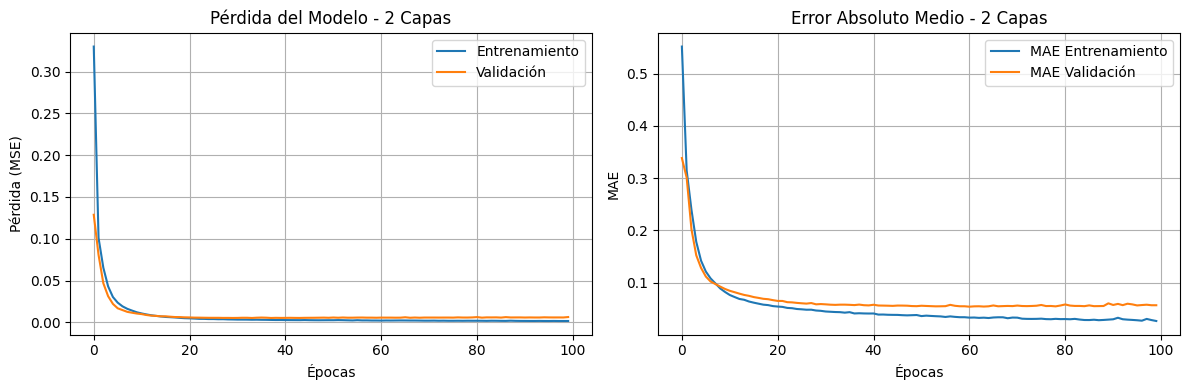

In [ ]:
# Punto 2: Red Neuronal multicapa
# Limpieza de sesión anterior
keras.backend.clear_session()

# Creación del modelo multicapa con 2 capas ocultas
model_2layer = Sequential()

# Primera capa oculta con 64 neuronas y función de activación ReLU
model_2layer.add(Dense(64, input_shape=(input_dim,), activation='relu'))

# Segunda capa oculta con 32 neuronas y función de activación ReLU
model_2layer.add(Dense(32, activation='relu'))

# Capa de salida con activación lineal para regresión
model_2layer.add(Dense(output_dim, activation='linear'))

# Compilación del modelo
model_2layer.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

print("Arquitectura del modelo multicapa:")
print(model_2layer.summary())

# Entrenamiento del modelo
red_2capas = model_2layer.fit(
    xTrain_scaled, yTrain,
    epochs=100,
    batch_size=32,
    validation_data=(xTest_scaled, yTest),
    verbose=1,
    callbacks=[PlotLossesKeras()]
)

# Predicciones
y_pred_2layer = model_2layer.predict(xTest_scaled)

# Métricas de evaluación
mae_2layer = mean_absolute_error(yTest, y_pred_2layer)
mse_2layer = mean_squared_error(yTest, y_pred_2layer)

print(f"\n RESULTADOS MODELO 2 CAPAS ")
print(f"Error Absoluto Medio (MAE): {mae_2layer:.4f}")
print(f"Error Cuadrático Medio (MSE): {mse_2layer:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {np.sqrt(mse_2layer):.4f}")

# Gráfico de pérdida
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(red_2capas.history['loss'], label='Entrenamiento')
plt.plot(red_2capas.history['val_loss'], label='Validación')
plt.title('Pérdida del Modelo - 2 Capas')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(red_2capas.history['mae'], label='MAE Entrenamiento')
plt.plot(red_2capas.history['val_mae'], label='MAE Validación')
plt.title('Error Absoluto Medio - 2 Capas')
plt.xlabel('Épocas')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## Punto 3  - Red Neuronal multicapa

En la celda 3 creen **una red neuronal con más de una capa con la librería Keras, usando early stopping y dropout,** que prediga la probabilidad de admisión de los estudiantes con los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador, el número de épocas y el número de neuronas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

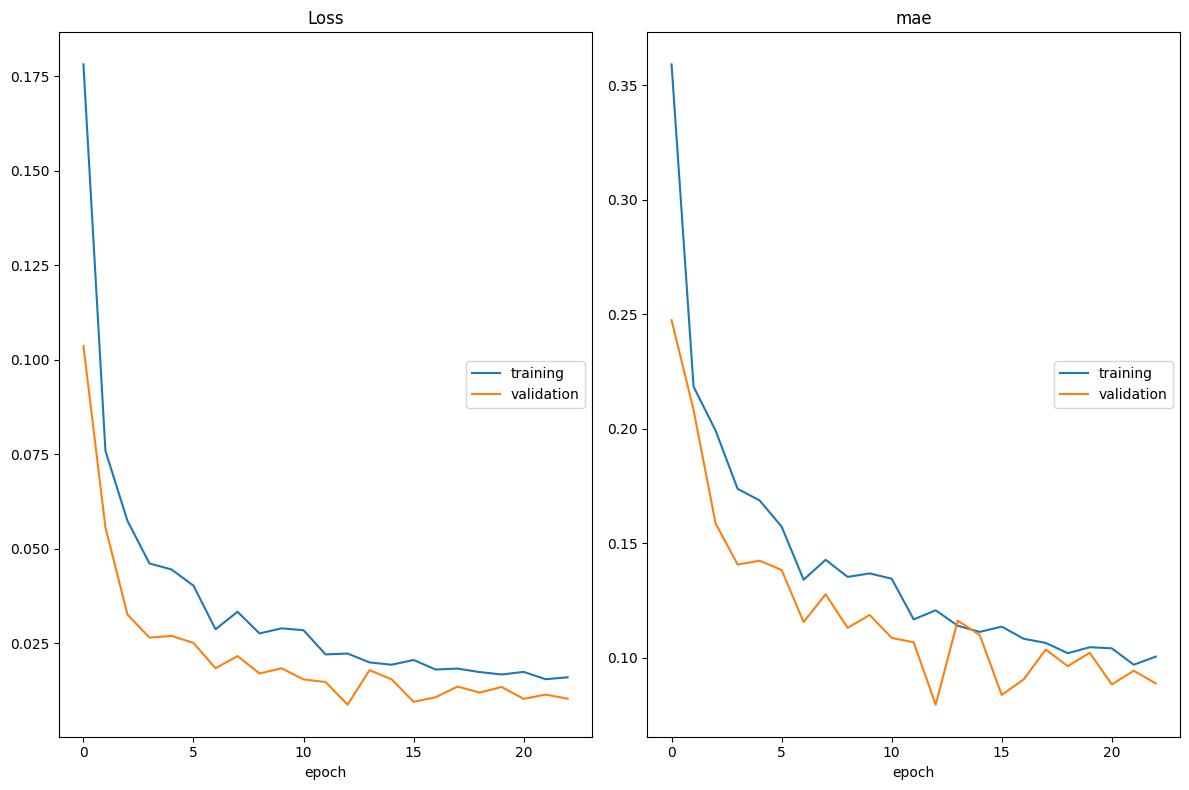

Loss
	training         	 (min:    0.016, max:    0.178, cur:    0.016)
	validation       	 (min:    0.009, max:    0.104, cur:    0.010)
mae
	training         	 (min:    0.097, max:    0.359, cur:    0.101)
	validation       	 (min:    0.080, max:    0.248, cur:    0.089)
11/11 [==============================] - 0s 38ms/step - loss: 0.0160 - mae: 0.1006 - val_loss: 0.0104 - val_mae: 0.0889
Epoch 23: early stopping
5/5 [==============================] - 0s 2ms/step

=== RESULTADOS MODELO CON REGULARIZACIÓN ===
Error Absoluto Medio (MAE): 0.0796
Error Cuadrático Medio (MSE): 0.0088
Raíz del Error Cuadrático Medio (RMSE): 0.0936
Épocas entrenadas: 23


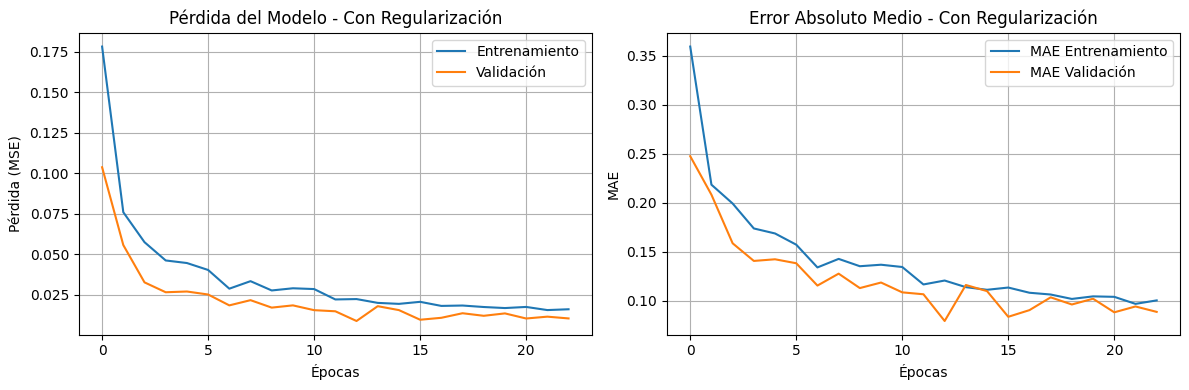

In [ ]:
# Punto 3: Red Neuronal multicapa con Early Stopping y Dropout
from keras.callbacks import ModelCheckpoint

# Limpieza de sesión anterior
keras.backend.clear_session()

# Creación del modelo multicapa con regularización
model_regularized = Sequential()

# Primera capa oculta con 128 neuronas 
model_regularized.add(Dense(128, input_shape=(input_dim,), activation='relu'))
# Dropout del 20%
model_regularized.add(Dropout(0.2))

# Segunda capa oculta con 64 neuronas 
model_regularized.add(Dense(64, activation='relu'))
# Dropout del 20% 
model_regularized.add(Dropout(0.2))

# Tercera capa oculta con 32 neuronas y función de activación ReLU
model_regularized.add(Dense(32, activation='relu'))
# Dropout del 10% 
model_regularized.add(Dropout(0.1))

# Capa de salida con activación lineal para regresión
model_regularized.add(Dense(output_dim, activation='linear'))

# Compilación del modelo
model_regularized.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

print("Arquitectura del modelo con regularización:")
print(model_regularized.summary())

# Configuración de Early Stopping
# Monitorea la pérdida de validación y se detiene si no mejora en 10 épocas
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Configuración de Model Checkpoint para guardar el mejor modelo
model_checkpoint = ModelCheckpoint(
    'best_model_regularized.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=0
)

# Entrenamiento del modelo con callbacks
multicapa = model_regularized.fit(
    xTrain_scaled, yTrain,
    epochs=200,  # Más épocas porque tenemos early stopping
    batch_size=32,
    validation_data=(xTest_scaled, yTest),
    verbose=1,
    callbacks=[early_stopping, model_checkpoint, PlotLossesKeras()]
)

# Predicciones
y_pred_regularized = model_regularized.predict(xTest_scaled)

# Métricas de evaluación
mae_regularized = mean_absolute_error(yTest, y_pred_regularized)
mse_regularized = mean_squared_error(yTest, y_pred_regularized)

print(f"\n=== RESULTADOS MODELO CON REGULARIZACIÓN ===")
print(f"Error Absoluto Medio (MAE): {mae_regularized:.4f}")
print(f"Error Cuadrático Medio (MSE): {mse_regularized:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {np.sqrt(mse_regularized):.4f}")
print(f"Épocas entrenadas: {len(multicapa.history['loss'])}")

# Gráfico de pérdida
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(multicapa.history['loss'], label='Entrenamiento')
plt.plot(multicapa.history['val_loss'], label='Validación')
plt.title('Pérdida del Modelo - Con Regularización')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(multicapa.history['mae'], label='MAE Entrenamiento')
plt.plot(multicapa.history['val_mae'], label='MAE Validación')
plt.title('Error Absoluto Medio - Con Regularización')
plt.xlabel('Épocas')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## Punto 4 - Comparación y análisis de resultados

En la celda 4 comparen los resultados obtenidos de las diferentes redes y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

                   Modelo       MAE       MSE      RMSE
0                  1 Capa  0.287503  0.134409  0.366618
1                 2 Capas  0.062754  0.006296  0.079347
2  Multicapa_Regularizado  0.079562  0.008765  0.093624


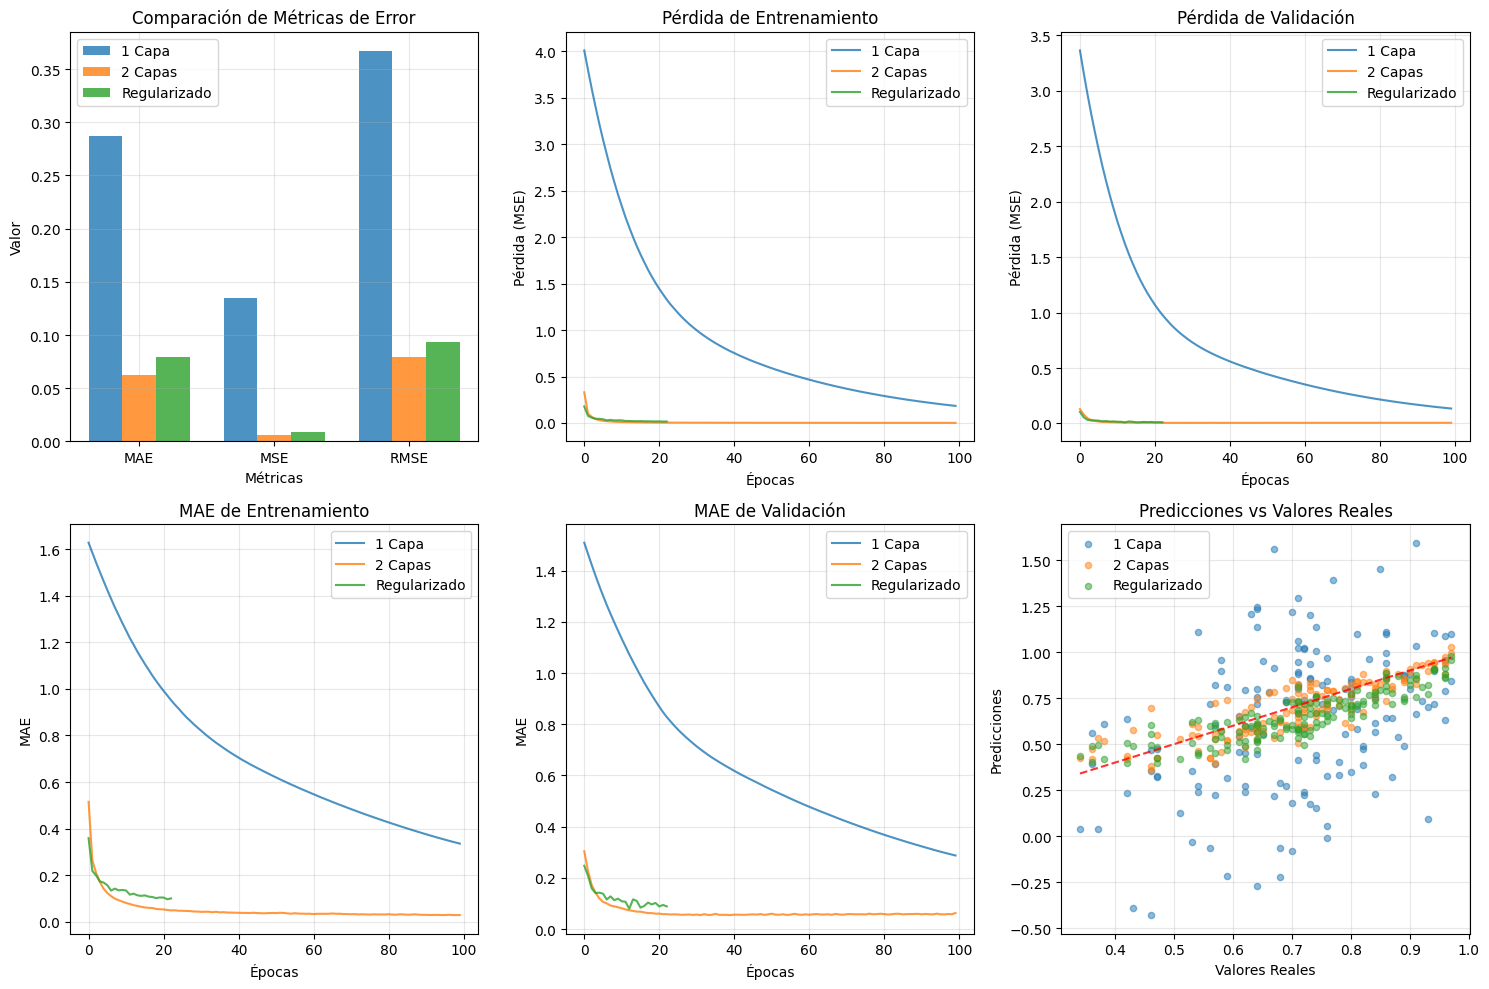

In [25]:
# Punto 4: Comparación y análisis de resultados
# Creación de DataFrame con resultados de todos los modelos
results_comparison = pd.DataFrame({
    'Modelo': ['1 Capa', '2 Capas', 'Multicapa_Regularizado'],
    'MAE': [mae_1layer, mae_2layer, mae_regularized],
    'MSE': [mse_1layer, mse_2layer, mse_regularized],
    'RMSE': [np.sqrt(mse_1layer), np.sqrt(mse_2layer), np.sqrt(mse_regularized)]
})

print(results_comparison)
# Gráficos comparativos
plt.figure(figsize=(15, 10))

# Gráfico 1: Comparación de métricas
plt.subplot(2, 3, 1)
metrics = ['MAE', 'MSE', 'RMSE']
x = np.arange(len(metrics))
width = 0.25

plt.bar(x - width, [mae_1layer, mse_1layer, np.sqrt(mse_1layer)], width, label='1 Capa', alpha=0.8)
plt.bar(x, [mae_2layer, mse_2layer, np.sqrt(mse_2layer)], width, label='2 Capas', alpha=0.8)
plt.bar(x + width, [mae_regularized, mse_regularized, np.sqrt(mse_regularized)], width, label='Regularizado', alpha=0.8)

plt.xlabel('Métricas')
plt.ylabel('Valor')
plt.title('Comparación de Métricas de Error')
plt.xticks(x, metrics)
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfico 2: Comparación de pérdidas de entrenamiento
plt.subplot(2, 3, 2)
plt.plot(red_1capa.history['loss'], label='1 Capa', alpha=0.8)
plt.plot(red_2capas.history['loss'], label='2 Capas', alpha=0.8)
plt.plot(multicapa.history['loss'], label='Regularizado', alpha=0.8)
plt.title('Pérdida de Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfico 3: Comparación de pérdidas de validación
plt.subplot(2, 3, 3)
plt.plot(red_1capa.history['val_loss'], label='1 Capa', alpha=0.8)
plt.plot(red_2capas.history['val_loss'], label='2 Capas', alpha=0.8)
plt.plot(multicapa.history['val_loss'], label='Regularizado', alpha=0.8)
plt.title('Pérdida de Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfico 4: Comparación de MAE de entrenamiento
plt.subplot(2, 3, 4)
plt.plot(red_1capa.history['mae'], label='1 Capa', alpha=0.8)
plt.plot(red_2capas.history['mae'], label='2 Capas', alpha=0.8)
plt.plot(multicapa.history['mae'], label='Regularizado', alpha=0.8)
plt.title('MAE de Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfico 5: Comparación de MAE de validación
plt.subplot(2, 3, 5)
plt.plot(red_1capa.history['val_mae'], label='1 Capa', alpha=0.8)
plt.plot(red_2capas.history['val_mae'], label='2 Capas', alpha=0.8)
plt.plot(multicapa.history['val_mae'], label='Regularizado', alpha=0.8)
plt.title('MAE de Validación')
plt.xlabel('Épocas')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfico 6: Scatter plot de predicciones vs valores reales
plt.subplot(2, 3, 6)
plt.scatter(yTest, y_pred_1layer, alpha=0.5, label='1 Capa', s=20)
plt.scatter(yTest, y_pred_2layer, alpha=0.5, label='2 Capas', s=20)
plt.scatter(yTest, y_pred_regularized, alpha=0.5, label='Regularizado', s=20)
plt.plot([yTest.min(), yTest.max()], [yTest.min(), yTest.max()], 'r--', alpha=0.8)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs Valores Reales')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


